The following code analyzes passing network data collected during the 2025 Women's Euro in Switzerland (). The analyzed dataset checks 

It is checked whether different properties of the opponents' and team's own network predict 

# Imports

In [89]:
import pandas as pd
import numpy as np
from pathlib import Path
from statsmodels.genmod.bayes_mixed_glm import PoissonBayesMixedGLM
import matplotlib.pyplot as plt

folder = Path("/Users/user/Dropbox/passing_network")

# Network data + other indices 

In [90]:
df2 = pd.read_excel("/Users/user/Dropbox/passing_network/tournament_data/all.xlsx")


In [91]:
df2.columns


Index(['match_id', 'match_date', 'team', 'possession_fotmob', 'xG_fotmob',
       'touches_in_opposition_box_fotmob', 'shots_on_target_fotmob',
       'accurate_passes_fotmob', 'accurate_passes_perc_fotmob',
       'possession_opponent_fotmob', 'xG_opponent_fotmob',
       'touches_in_opposition_box_opponent_fotmob',
       'shots_on_target_opponent_fotmob', 'accurate_passes_opponent_fotmob',
       'accurate_passes_perc_opponent_fotmob', 'stage', 'density',
       'degree_centralization', 'avg_clustering', 'transitivity', 'diameter',
       'convex_hull', 'total_passes', 'goals', 'shots', 'result1', 'result2',
       'shot_statsbomb_xg', 'density_opponents',
       'degree_centralization_opponents', 'avg_clustering_opponents',
       'transitivity_opponents', 'diameter_opponents', 'convex_hull_opponents',
       'total_passes_opponents', 'goals_opponents', 'shots_opponents',
       'result1_opponents', 'result2_opponents',
       'shot_statsbomb_xg_opponents'],
      dtype='str')

# Exploratory data analysis 

In [92]:
df2.describe()

,match_id,possession_fotmob,xG_fotmob,touches_in_opposition_box_fotmob,shots_on_target_fotmob,accurate_passes_fotmob,accurate_passes_perc_fotmob,possession_opponent_fotmob,xG_opponent_fotmob,touches_in_opposition_box_opponent_fotmob,...,degree_centralization_opponents,avg_clustering_opponents,transitivity_opponents,diameter_opponents,convex_hull_opponents,total_passes_opponents,goals_opponents,shots_opponents,result2_opponents,shot_statsbomb_xg_opponents
count,6.200000e+01,62.00000,62.000000,62.000000,62.000000,62.000000,62.000000,62.00000,62.000000,62.000000,...,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,52.000000,62.000000
mean,4.003442e+06,0.50000,1.723226,25.983871,5.016129,327.225806,76.790323,50.00000,1.723226,25.983871,...,0.222247,0.210967,0.915626,2.096774,2123.019751,367.387097,1.709677,12.612903,0.500000,0.107824
std,8.589419e+03,0.14871,1.105332,14.767590,3.059476,148.694805,8.454579,14.87103,1.105332,14.767590,...,0.067070,0.047583,0.048767,0.298064,342.802133,145.190813,1.475339,6.047232,0.504878,0.053721
min,3.998836e+06,0.20000,0.120000,5.000000,0.000000,113.000000,51.000000,20.00000,0.120000,5.000000,...,0.088889,0.141483,0.750000,2.000000,1199.326638,122.000000,0.000000,4.000000,0.000000,0.009931
25%,3.998843e+06,0.42000,0.940000,15.250000,3.000000,225.000000,73.000000,42.00000,0.940000,15.250000,...,0.177778,0.168933,0.887755,2.000000,1893.058938,269.250000,1.000000,8.000000,0.000000,0.073612
50%,3.998851e+06,0.50000,1.525000,24.500000,4.500000,295.500000,77.000000,50.00000,1.525000,24.500000,...,0.222222,0.205073,0.923621,2.000000,2139.729267,337.500000,1.000000,11.500000,0.500000,0.097586
75%,3.998859e+06,0.58000,2.450000,32.000000,7.000000,393.750000,82.000000,58.00000,2.450000,32.000000,...,0.277778,0.249870,0.947075,2.000000,2347.115657,437.000000,2.000000,16.000000,1.000000,0.129416
max,4.020846e+06,0.80000,5.570000,62.000000,18.000000,717.000000,91.000000,80.00000,5.570000,62.000000,...,0.366667,0.328689,1.000000,3.000000,2852.839936,768.000000,6.000000,32.000000,1.000000,0.241698


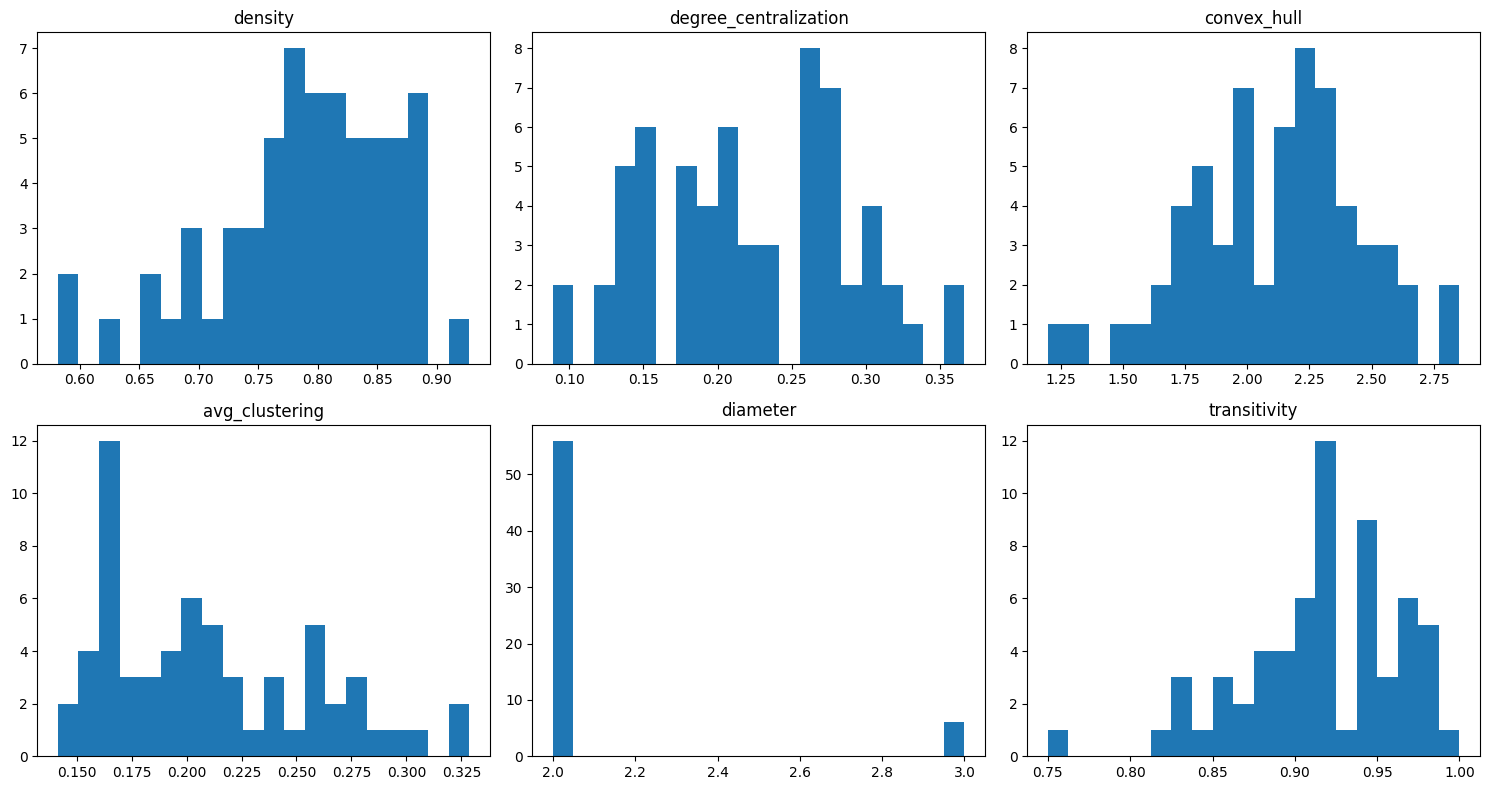

In [140]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

variables = [
    'density',
    'degree_centralization',
    'convex_hull',
    'avg_clustering',
    'diameter',
    'transitivity'
]

for ax, var in zip(axes.flatten(), variables):
    ax.hist(df2[var].dropna(), bins=20)
    ax.set_title(var)

plt.tight_layout()
plt.show()

In [103]:
df2["diff_xG_goals"] = df2["xG_fotmob"] - df2["goals"]

(array([ 1.,  1.,  1.,  3., 11.,  5., 17., 13.,  8.,  2.]),
 array([-3.14 , -2.636, -2.132, -1.628, -1.124, -0.62 , -0.116,  0.388,
         0.892,  1.396,  1.9  ]),
 <BarContainer object of 10 artists>)

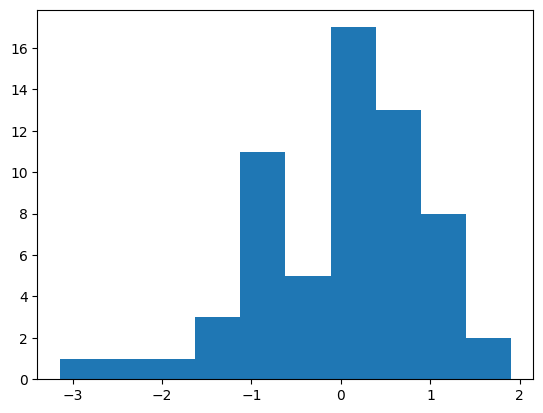

In [104]:
plt.hist(df2["diff_xG_goals"])

In [106]:
df2.loc[df2["diff_xG_goals"].idxmin()]

match_id                                           3998847
match_date                                      2025-07-07
team                                         Spain Women's
possession_fotmob                                      0.8
xG_fotmob                                             2.86
touches_in_opposition_box_fotmob                        59
shots_on_target_fotmob                                   9
accurate_passes_fotmob                                 659
accurate_passes_perc_fotmob                             89
possession_opponent_fotmob                              20
xG_opponent_fotmob                                    0.76
touches_in_opposition_box_opponent_fotmob                5
shots_on_target_opponent_fotmob                          3
accurate_passes_opponent_fotmob                        113
accurate_passes_perc_opponent_fotmob                    62
stage                                          Group stage
density                                           0.8909

In [107]:
for i in range(0, len(df2)):
    if df2.loc[i, "match_id"] == 3998847:
        print(df2.loc[i, "team"])

Spain Women's
Belgium Women's


In [141]:
df2.loc[df2["diff_xG_goals"].idxmax()]

match_id                                           4018356
match_date                                      2025-07-18
team                                         Spain Women's
possession_fotmob                                     0.72
xG_fotmob                                              3.9
touches_in_opposition_box_fotmob                        56
shots_on_target_fotmob                                   6
accurate_passes_fotmob                                 581
accurate_passes_perc_fotmob                             88
possession_opponent_fotmob                              28
xG_opponent_fotmob                                    0.12
touches_in_opposition_box_opponent_fotmob                6
shots_on_target_opponent_fotmob                          0
accurate_passes_opponent_fotmob                        183
accurate_passes_perc_opponent_fotmob                    71
stage                                        Quarter-final
density                                           0.8818

In [108]:
for i in range(0, len(df2)):
    if df2.loc[i, "diff_xG_goals"] > 0:
        print(df2.loc[i, "match_id"], df2.loc[i, "team"])

4020846 England Women's
3998852 Switzerland Women's
3998840 Germany Women's
3998855 Italy Women's
3998854 Portugal Women's
4018356 Spain Women's
4018355 England Women's
3998843 France Women's
3998845 WNT Finland
3998849 Germany Women's
4020077 Spain Women's
3998850 Wales W
4018357 Germany Women's
3998852 WNT Finland
3998857 Denmark Women's
3998848 Sweden Women's
3998837 Switzerland Women's
4018357 France Women's
4020846 Spain Women's
4018354 Norway Women's
3998836 Iceland Women's
4018355 Sweden Women's
3998851 Netherlands Women's
3998841 Denmark Women's
4018356 Switzerland Women's
3998838 Italy Women's
3998838 Belgium Women's
4020005 England Women's
3998842 Wales W
3998840 Poland Women's
4020077 Germany Women's
3998841 Sweden Women's
3998846 Italy Women's
3998848 Poland Women's
3998844 Iceland Women's
4020005 Italy Women's
3998839 Portugal Women's


# Team hierarchies

In [112]:
df2.groupby("team")["shots"].mean().sort_values(ascending = False)

team
Spain Women's          21.666667
France Women's         14.750000
Sweden Women's         14.500000
England Women's        14.166667
Germany Women's        14.000000
Italy Women's          12.000000
Denmark Women's        12.000000
WNT Finland            11.666667
Iceland Women's        11.666667
Switzerland Women's    11.000000
Poland Women's         11.000000
Norway Women's         10.500000
Netherlands Women's    10.000000
Portugal Women's       10.000000
Belgium Women's         8.333333
Wales W                 5.666667
Denmark Women's         5.000000
Name: shots, dtype: float64

In [114]:
df2.groupby("team")["shots_on_target_fotmob"].mean().sort_values(ascending = False)

team
Spain Women's          7.666667
France Women's         7.250000
Wales W                6.666667
Sweden Women's         6.000000
Denmark Women's        6.000000
England Women's        5.833333
Italy Women's          5.200000
WNT Finland            4.333333
Germany Women's        4.200000
Netherlands Women's    4.000000
Denmark Women's        4.000000
Switzerland Women's    3.750000
Poland Women's         3.666667
Iceland Women's        3.666667
Norway Women's         3.500000
Portugal Women's       3.000000
Belgium Women's        3.000000
Name: shots_on_target_fotmob, dtype: float64

In [109]:
df2.groupby("team")["xG_fotmob"].mean().sort_values(ascending = False)

team
Spain Women's          2.950000
Sweden Women's         2.872500
England Women's        2.601667
France Women's         2.547500
Germany Women's        1.714000
Norway Women's         1.647500
Italy Women's          1.574000
Denmark Women's        1.455000
Iceland Women's        1.430000
Belgium Women's        1.156667
Poland Women's         1.126667
WNT Finland            1.110000
Netherlands Women's    1.023333
Portugal Women's       0.960000
Switzerland Women's    0.815000
Wales W                0.630000
Denmark Women's        0.340000
Name: xG_fotmob, dtype: float64

In [86]:
df2.groupby("team")["goals"].mean().sort_values(ascending = False)

team
France Women's         3.000000
Spain Women's          3.000000
England Women's        2.666667
Sweden Women's         2.500000
Norway Women's         2.250000
Netherlands Women's    1.666667
Belgium Women's        1.333333
Germany Women's        1.250000
Italy Women's          1.200000
Iceland Women's        1.000000
Denmark Women's        1.000000
Poland Women's         1.000000
German Women's         1.000000
Denmark Women's        1.000000
Switzerland Women's    1.000000
WNT Finland            1.000000
Portugal Women's       0.666667
Wales W                0.666667
Name: goals, dtype: float64

# Team's passing network effects

## Shots

### Traditional Poisson model

In [118]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.glm(
    formula="shots ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  shots   No. Observations:                   62
Model:                            GLM   Df Residuals:                       56
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -181.94
Date:                Tue, 01 Sep 2026   Deviance:                       99.140
Time:                        22:24:58   Pearson chi2:                     97.2
No. Iterations:                     4   Pseudo R-squ. (CS):             0.6987
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.30

### Multi-level, cross-classified Poisson model

In [116]:
from statsmodels.genmod.bayes_mixed_glm import PoissonBayesMixedGLM

random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "shots ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                     Poisson Mixed GLM Results
                      Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------------
Intercept                M    -0.0802   0.0356                      
density                  M     2.3432   0.0439                      
degree_centralization    M    -1.6510   0.1629                      
convex_hull              M     0.5296   0.0162                      
avg_clustering           M     1.0054   0.1651                      
diameter                 M    -0.1383   0.0171                      
team                     V    -1.7982   0.1784 0.166   0.116   0.237
match                    V    -1.8104   0.1298 0.164   0.126   0.212
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


## Shots on target

### Traditional Poisson model

In [121]:
model = smf.glm(
    formula="shots_on_target_fotmob ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                   Generalized Linear Model Regression Results                    
Dep. Variable:     shots_on_target_fotmob   No. Observations:                   62
Model:                                GLM   Df Residuals:                       56
Model Family:                     Poisson   Df Model:                            5
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -148.97
Date:                    Tue, 01 Sep 2026   Deviance:                       96.449
Time:                            22:26:10   Pearson chi2:                     101.
No. Iterations:                         4   Pseudo R-squ. (CS):             0.2576
Covariance Type:                nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

### Multi-level, cross-classified Poisson model

In [132]:
from statsmodels.genmod.bayes_mixed_glm import PoissonBayesMixedGLM

random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "shots_on_target_fotmob ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                     Poisson Mixed GLM Results
                      Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------------
Intercept                M     1.3193   0.0565                      
density                  M     1.4102   0.0699                      
degree_centralization    M    -1.9145   0.2554                      
convex_hull              M     0.0564   0.0261                      
avg_clustering           M     0.6080   0.2585                      
diameter                 M    -0.3433   0.0272                      
team                     V    -1.4006   0.1762 0.246   0.173   0.351
match                    V    -1.9112   0.1300 0.148   0.114   0.192
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


## xG

### Traditional Poisson model

In [129]:
X = df2[['density', 'degree_centralization', 'convex_hull', 'avg_clustering', 'diameter']]
Y = df2['xG_fotmob']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              xG_fotmob   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     4.960
Date:                Tue, 01 Sep 2026   Prob (F-statistic):           0.000789
Time:                        22:31:35   Log-Likelihood:                -82.313
No. Observations:                  62   AIC:                             176.6
Df Residuals:                      56   BIC:                             189.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -3.65

### Multi-level cross-classified model

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.glm(
    formula="""
        xG_fotmob ~ 
        density + 
        degree_centralization + 
        convex_hull + 
        avg_clustering + 
        diameter
    """,
    data=df2,
    family=sm.families.Gaussian()
).fit()

print(model.summary())

model.pseudo_rsquared(kind="cs")

## Goals

### Traditional Poisson model

In [122]:
model = smf.glm(
    formula="goals ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                   62
Model:                            GLM   Df Residuals:                       56
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -90.560
Date:                Tue, 01 Sep 2026   Deviance:                       53.616
Time:                        22:26:31   Pearson chi2:                     54.2
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3508
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -6.94

### Multi-level, cross-classified Poisson model

In [133]:
from statsmodels.genmod.bayes_mixed_glm import PoissonBayesMixedGLM

random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "goals ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                     Poisson Mixed GLM Results
                      Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------------
Intercept                M    -2.0625   0.0964                      
density                  M     2.0108   0.1186                      
degree_centralization    M    -2.6354   0.4372                      
convex_hull              M     0.6201   0.0437                      
avg_clustering           M    -0.3704   0.4400                      
diameter                 M     0.0998   0.0461                      
team                     V    -1.5405   0.1770 0.214   0.150   0.305
match                    V    -1.3256   0.1287 0.266   0.205   0.344
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


# Opponents passing network effects 

## Shots

### Traditional Poisson model

In [123]:
model = smf.glm(
    formula="shots ~ density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  shots   No. Observations:                   62
Model:                            GLM   Df Residuals:                       56
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -175.19
Date:                Tue, 01 Sep 2026   Deviance:                       85.631
Time:                        22:27:17   Pearson chi2:                     84.5
No. Iterations:                     4   Pseudo R-squ. (CS):             0.7577
Covariance Type:            nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

### Multi-level, cross-classified Poisson model

In [134]:
random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "shots ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                     Poisson Mixed GLM Results
                      Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------------
Intercept                M    -0.0802   0.0356                      
density                  M     2.3432   0.0439                      
degree_centralization    M    -1.6510   0.1629                      
convex_hull              M     0.5296   0.0162                      
avg_clustering           M     1.0054   0.1651                      
diameter                 M    -0.1383   0.0171                      
team                     V    -1.7982   0.1784 0.166   0.116   0.237
match                    V    -1.8104   0.1298 0.164   0.126   0.212
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


## Shots on target

### Traditional Poisson model

In [124]:
model = smf.glm(
    formula="shots_on_target_fotmob ~ density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                   Generalized Linear Model Regression Results                    
Dep. Variable:     shots_on_target_fotmob   No. Observations:                   62
Model:                                GLM   Df Residuals:                       56
Model Family:                     Poisson   Df Model:                            5
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -150.22
Date:                    Tue, 01 Sep 2026   Deviance:                       98.934
Time:                            22:27:46   Pearson chi2:                     111.
No. Iterations:                         4   Pseudo R-squ. (CS):             0.2272
Covariance Type:                nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

### Multi-level, cross-classified Poisson model

In [ ]:
random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "shots_on_target_fotmob ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

## xG

### Traditional model

In [130]:
X = df2[['density_opponents', 'degree_centralization_opponents', 'convex_hull_opponents', 'avg_clustering_opponents', 'diameter_opponents']]
Y = df2['xG_fotmob']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              xG_fotmob   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     7.033
Date:                Tue, 01 Sep 2026   Prob (F-statistic):           3.67e-05
Time:                        22:33:01   Log-Likelihood:                -78.573
No. Observations:                  62   AIC:                             169.1
Df Residuals:                      56   BIC:                             181.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

### Multi-level, cross-classified model

In [ ]:
model = smf.glm(
    formula="""
        xG_fotmob ~ 
        density_opponents + 
        degree_centralization_opponents + 
        convex_hull_opponents + 
        avg_clustering_opponents + 
        diameter_opponents
    """,
    data=df2,
    family=sm.families.Gaussian()
).fit()

print(model.summary())

model.pseudo_rsquared(kind="cs")

## Goals

### Traditional Poisson model

In [125]:
model = smf.glm(
    formula="goals~ density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                   62
Model:                            GLM   Df Residuals:                       56
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -93.451
Date:                Tue, 01 Sep 2026   Deviance:                       59.399
Time:                        22:27:56   Pearson chi2:                     52.1
No. Iterations:                     4   Pseudo R-squ. (CS):             0.2874
Covariance Type:            nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

### Multi-level, cross-classified Poisson model

In [ ]:
random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "goals ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

# Joint effects

## Shots

### Traditional Poisson

In [126]:
model = smf.glm(
    formula="shots ~ density + degree_centralization + convex_hull + avg_clustering + diameter + density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  shots   No. Observations:                   62
Model:                            GLM   Df Residuals:                       51
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -158.24
Date:                Tue, 01 Sep 2026   Deviance:                       51.739
Time:                        22:28:43   Pearson chi2:                     52.0
No. Iterations:                     4   Pseudo R-squ. (CS):             0.8597
Covariance Type:            nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

### Multi-level, cross-classified Poisson model

In [135]:
random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "shots ~ density + degree_centralization + convex_hull + avg_clustering + diameter + density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                         Poisson Mixed GLM Results
                                Type Post. Mean Post. SD  SD SD (LB) SD (UB)
----------------------------------------------------------------------------
Intercept                          M        nan      nan                    
density                            M        nan      nan                    
degree_centralization              M        nan      nan                    
convex_hull                        M        nan      nan                    
avg_clustering                     M        nan      nan                    
diameter                           M        nan      nan                    
density_opponents                  M        nan      nan                    
degree_centralization_opponents    M        nan      nan                    
convex_hull_opponents              M        nan      nan                    
avg_clustering_opponents           M        nan      nan                    
diameter_opponents       

/Users/user/.pyenv/versions/3.14.2/lib/python3.14/site-packages/statsmodels/genmod/bayes_mixed_glm.py:1169: RuntimeWarning: overflow encountered in exp
  return -np.exp(tm + np.sqrt(tv) * z)
/Users/user/.pyenv/versions/3.14.2/lib/python3.14/site-packages/statsmodels/genmod/bayes_mixed_glm.py:1184: RuntimeWarning: overflow encountered in exp
  y = -np.exp(tm + np.sqrt(tv) * z)
/Users/user/.pyenv/versions/3.14.2/lib/python3.14/site-packages/scipy/optimize/_linesearch.py:161: RuntimeWarning: invalid value encountered in scalar subtract
  alpha1 = min(1.0, 1.01*2*(phi0 - old_phi0)/derphi0)
/Users/user/.pyenv/versions/3.14.2/lib/python3.14/site-packages/scipy/optimize/_linesearch.py:395: RuntimeWarning: invalid value encountered in scalar subtract
  alpha1 = min(1.0, 1.01*2*(phi0 - old_phi0)/derphi0)
/Users/user/.pyenv/versions/3.14.2/lib/python3.14/site-packages/statsmodels/genmod/bayes_mixed_glm.py:793: UserWarning: VB fitting did not converge
  warnings.warn("VB fitting did not converge"

## Shots on target 

### Traditional Poisson model

In [127]:
model = smf.glm(
    formula="shots_on_target_fotmob ~ density + degree_centralization + convex_hull + avg_clustering + diameter + density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                   Generalized Linear Model Regression Results                    
Dep. Variable:     shots_on_target_fotmob   No. Observations:                   62
Model:                                GLM   Df Residuals:                       51
Model Family:                     Poisson   Df Model:                           10
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -144.31
Date:                    Tue, 01 Sep 2026   Deviance:                       87.113
Time:                            22:29:49   Pearson chi2:                     97.1
No. Iterations:                         5   Pseudo R-squ. (CS):             0.3614
Covariance Type:                nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

### Multi-level, cross-classified Poisson model

In [ ]:
random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "shots_on_target_fotmob ~ density + degree_centralization + convex_hull + avg_clustering + diameter + density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                         Poisson Mixed GLM Results
                                Type Post. Mean Post. SD  SD SD (LB) SD (UB)
----------------------------------------------------------------------------
Intercept                          M        nan      nan                    
density                            M        nan      nan                    
degree_centralization              M        nan      nan                    
convex_hull                        M        nan      nan                    
avg_clustering                     M        nan      nan                    
diameter                           M        nan      nan                    
density_opponents                  M        nan      nan                    
degree_centralization_opponents    M        nan      nan                    
convex_hull_opponents              M        nan      nan                    
avg_clustering_opponents           M        nan      nan                    
diameter_opponents       

/Users/user/.pyenv/versions/3.14.2/lib/python3.14/site-packages/statsmodels/genmod/bayes_mixed_glm.py:1169: RuntimeWarning: overflow encountered in exp
  return -np.exp(tm + np.sqrt(tv) * z)
/Users/user/.pyenv/versions/3.14.2/lib/python3.14/site-packages/statsmodels/genmod/bayes_mixed_glm.py:1184: RuntimeWarning: overflow encountered in exp
  y = -np.exp(tm + np.sqrt(tv) * z)
/Users/user/.pyenv/versions/3.14.2/lib/python3.14/site-packages/scipy/optimize/_linesearch.py:161: RuntimeWarning: invalid value encountered in scalar subtract
  alpha1 = min(1.0, 1.01*2*(phi0 - old_phi0)/derphi0)
/Users/user/.pyenv/versions/3.14.2/lib/python3.14/site-packages/scipy/optimize/_linesearch.py:395: RuntimeWarning: invalid value encountered in scalar subtract
  alpha1 = min(1.0, 1.01*2*(phi0 - old_phi0)/derphi0)
/Users/user/.pyenv/versions/3.14.2/lib/python3.14/site-packages/statsmodels/genmod/bayes_mixed_glm.py:793: UserWarning: VB fitting did not converge
  warnings.warn("VB fitting did not converge"

## xG

### Traditional model

In [131]:
X = df2[['density', 'degree_centralization', 'convex_hull', 'avg_clustering', 'diameter', 'density_opponents', 'degree_centralization_opponents', 'convex_hull_opponents', 'avg_clustering_opponents', 'diameter_opponents']]
Y = df2['xG_fotmob']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              xG_fotmob   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     5.639
Date:                Tue, 01 Sep 2026   Prob (F-statistic):           1.27e-05
Time:                        22:34:32   Log-Likelihood:                -70.597
No. Observations:                  62   AIC:                             163.2
Df Residuals:                      51   BIC:                             186.6
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

### Multi-level cross-classified model

In [ ]:
model = smf.glm(
    formula="""
        xG_fotmob ~ 
        density + 
        degree_centralization +
        convex_hull_opponents +
        diameter +
        density_opponents + 
        degree_centralization_opponents + 
        convex_hull_opponents + 
        avg_clustering_opponents + 
        diameter_opponents 
    """,
    data=df2,
    family=sm.families.Gaussian()
).fit()

print(model.summary())

model.pseudo_rsquared(kind="cs")

## Goals

### Traditional Poisson model

In [128]:
model = smf.glm(
    formula="goals ~ density + degree_centralization + convex_hull + avg_clustering + diameter + density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                   62
Model:                            GLM   Df Residuals:                       51
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -84.262
Date:                Tue, 01 Sep 2026   Deviance:                       41.020
Time:                        22:30:02   Pearson chi2:                     38.3
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4702
Covariance Type:            nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

### Multi-level, cross-classified Poisson model

In [ ]:
random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "goals ~ density + degree_centralization + convex_hull + avg_clustering + diameter + density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

# Interaction analysis